In [1]:
# Cell 1: Installation and Setup
!pip install spacy[cuda-autodetect] nltk requests beautifulsoup4
!python -m spacy download en_core_web_sm
!python -m spacy download en_core_web_trf

import spacy
import requests
from bs4 import BeautifulSoup
import cupy as cp  # CUDA accelerated computing
import torch
print("CUDA available:", torch.cuda.is_available())
print("Number of GPUs:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("Current GPU:", torch.cuda.get_device_name(0))

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 8.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.8/81.8 MB 17.9 MB/s eta 0:00:0000:0100:01
  Created wheel for cupy-wheel: filename=cupy_wheel-12.3.0-py3-none-any.whl size=993 sha256=e38f0c68abfa44aed92ac1b17e143526a0a4daa1f0746df694508091c15642a8
  Stored in directory: /tmp/pip-ephem-wheel-cache-x9sma51a/wheels/e5/f3/9d/f049ae6f63a76342d52b752cfe2eabd7b96dcc363506bb00fa
Successfully built cupy-wheel
  Attempting uninstall: cupy-cuda12x
    Found existing installation: cupy-cuda12x 13.0.0
    Uninstalling cupy-cuda12x-13.0.0:
      Successfully uninstalled cupy-cuda12x-13.0.0

[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: python -m pip install --upgrade pip
Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
     ━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
# Cell 2: Utility Functions
def fetch_text_from_url(url):
    """Fetch and clean text from a URL"""
    try:
        response = requests.get(url)
        soup = BeautifulSoup(response.text, 'html.parser')
        
        # Remove script and style elements
        for script in soup(["script", "style"]):
            script.decompose()
            
        # Get text and clean it
        text = soup.get_text()
        lines = (line.strip() for line in text.splitlines())
        chunks = (phrase.strip() for line in lines for phrase in line.split("  "))
        text = ' '.join(chunk for chunk in chunks if chunk)
        
        return text[:5000]  # Return first 5000 characters
    except Exception as e:
        print(f"Error fetching URL: {e}")
        return None

# Use a sample URL
url = "https://en.wikipedia.org/wiki/Natural_language_processing"
text = fetch_text_from_url(url)
if not text:
    text = "Natural language processing (NLP) is a field of artificial intelligence that focuses on the interaction between computers and humans through natural language. The ultimate objective of NLP is to read, decipher, understand, and make sense of human language in a valuable way. Many modern NLP approaches use deep learning techniques which require significant computational power, making them ideal for GPU-accelerated environments like the NVIDIA DGX A100."
    
print("Sample text:", text[:200] + "...")

Sample text: Please set a user-agent and respect our robot policy https://w.wiki/4wJS. See also T400119....


/tmp/ipykernel_726508/2330891408.py:6: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  soup = BeautifulSoup(response.text, 'html.parser')


In [3]:
# Cell 3: Basic NLP Processing with GPU Acceleration
# Check if we can use the transformer model (more accurate but requires more resources)
use_gpu = torch.cuda.is_available()
if use_gpu:
    print("Using GPU-accelerated transformer model")
    nlp = spacy.load("en_core_web_trf")
else:
    print("Using CPU-based small model")
    nlp = spacy.load("en_core_web_sm")

# Process text
doc = nlp(text)

print(f"Processed {len(doc)} characters")
print(f"Found {len(list(doc.sents))} sentences")
print(f"Found {len([token for token in doc if not token.is_space])} tokens")

Using GPU-accelerated transformer model
Processed 17 characters
Found 2 sentences
Found 17 tokens


In [6]:
# Cell 4: Visualization in Notebook
from spacy import displacy

# Display named entities
displacy.render(doc, style="ent", jupyter=True)

# Display dependency parse for first sentence
first_sentence = list(doc.sents)[0]
displacy.render(first_sentence, style="dep", jupyter=True, options={"compact": True})

In [9]:
# Cell 5: Performance Comparison (GPU vs CPU if available)
import time

if use_gpu:
    # Time GPU processing
    start_time = time.time()
    gpu_doc = nlp(text)
    gpu_time = time.time() - start_time
    
    # Switch to CPU model and time
    cpu_nlp = spacy.load("en_core_web_sm")
    start_time = time.time()
    cpu_doc = cpu_nlp(text)
    cpu_time = time.time() - start_time
    
    print(f"GPU processing time: {gpu_time:.4f} seconds")
    print(f"CPU processing time: {cpu_time:.4f} seconds")
    print(f"Speedup: {cpu_time/gpu_time:.2f}x")

GPU processing time: 0.8712 seconds
CPU processing time: 0.0060 seconds
Speedup: 0.01x


In [10]:
# Cell 1: Setup and Imports
import spacy
from nltk.stem import PorterStemmer, SnowballStemmer
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.stem import WordNetLemmatizer
import matplotlib.pyplot as plt
import seaborn as sns

# Load the appropriate model
use_gpu = torch.cuda.is_available()
nlp = spacy.load("en_core_web_trf") if use_gpu else spacy.load("en_core_web_sm")

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [11]:
# Cell 2: Compare Stemming and Lemmatization
# Initialize stemmers and lemmatizer
porter = PorterStemmer()
snowball = SnowballStemmer("english")
wordnet_lemmatizer = WordNetLemmatizer()

# Sample words for comparison
sample_words = ["running", "happily", "better", "was", "books", "interesting", "studies", "amazingly"]

# Create comparison table
comparison_data = []
for word in sample_words:
    # Get spaCy lemma
    spacy_lemma = nlp(word)[0].lemma_
    
    # Get other stem/lemmas
    porter_stem = porter.stem(word)
    snowball_stem = snowball.stem(word)
    wordnet_lemma = wordnet_lemmatizer.lemmatize(word)
    
    comparison_data.append({
        "Word": word,
        "Porter": porter_stem,
        "Snowball": snowball_stem,
        "WordNet": wordnet_lemma,
        "spaCy": spacy_lemma
    })

# Display as table
import pandas as pd
df = pd.DataFrame(comparison_data)
df

,Word,Porter,Snowball,WordNet,spaCy
0,running,run,run,running,run
1,happily,happili,happili,happily,happily
2,better,better,better,better,well
3,was,wa,was,wa,be
4,books,book,book,book,book
5,interesting,interest,interest,interesting,interesting
6,studies,studi,studi,study,study
7,amazingly,amazingli,amaz,amazingly,amazingly


In [12]:
# Cell 2: Compare Stemming and Lemmatization
# Initialize stemmers and lemmatizer
porter = PorterStemmer()
snowball = SnowballStemmer("english")
wordnet_lemmatizer = WordNetLemmatizer()

# Sample words for comparison
sample_words = ["running", "happily", "better", "was", "books", "interesting", "studies", "amazingly"]

# Create comparison table
comparison_data = []
for word in sample_words:
    # Get spaCy lemma
    spacy_lemma = nlp(word)[0].lemma_
    
    # Get other stem/lemmas
    porter_stem = porter.stem(word)
    snowball_stem = snowball.stem(word)
    wordnet_lemma = wordnet_lemmatizer.lemmatize(word)
    
    comparison_data.append({
        "Word": word,
        "Porter": porter_stem,
        "Snowball": snowball_stem,
        "WordNet": wordnet_lemma,
        "spaCy": spacy_lemma
    })

# Display as table
import pandas as pd
df = pd.DataFrame(comparison_data)
df

,Word,Porter,Snowball,WordNet,spaCy
0,running,run,run,running,run
1,happily,happili,happili,happily,happily
2,better,better,better,better,well
3,was,wa,was,wa,be
4,books,book,book,book,book
5,interesting,interest,interest,interesting,interesting
6,studies,studi,studi,study,study
7,amazingly,amazingli,amaz,amazingly,amazingly


In [13]:
# Cell 2: Compare Stemming and Lemmatization
# Initialize stemmers and lemmatizer
porter = PorterStemmer()
snowball = SnowballStemmer("english")
wordnet_lemmatizer = WordNetLemmatizer()

# Sample words for comparison
sample_words = ["running", "happily", "better", "was", "books", "interesting", "studies", "amazingly"]

# Create comparison table
comparison_data = []
for word in sample_words:
    # Get spaCy lemma
    spacy_lemma = nlp(word)[0].lemma_
    
    # Get other stem/lemmas
    porter_stem = porter.stem(word)
    snowball_stem = snowball.stem(word)
    wordnet_lemma = wordnet_lemmatizer.lemmatize(word)
    
    comparison_data.append({
        "Word": word,
        "Porter": porter_stem,
        "Snowball": snowball_stem,
        "WordNet": wordnet_lemma,
        "spaCy": spacy_lemma
    })

# Display as table
import pandas as pd
df = pd.DataFrame(comparison_data)
df

,Word,Porter,Snowball,WordNet,spaCy
0,running,run,run,running,run
1,happily,happili,happili,happily,happily
2,better,better,better,better,well
3,was,wa,was,wa,be
4,books,book,book,book,book
5,interesting,interest,interest,interesting,interesting
6,studies,studi,studi,study,study
7,amazingly,amazingli,amaz,amazingly,amazingly


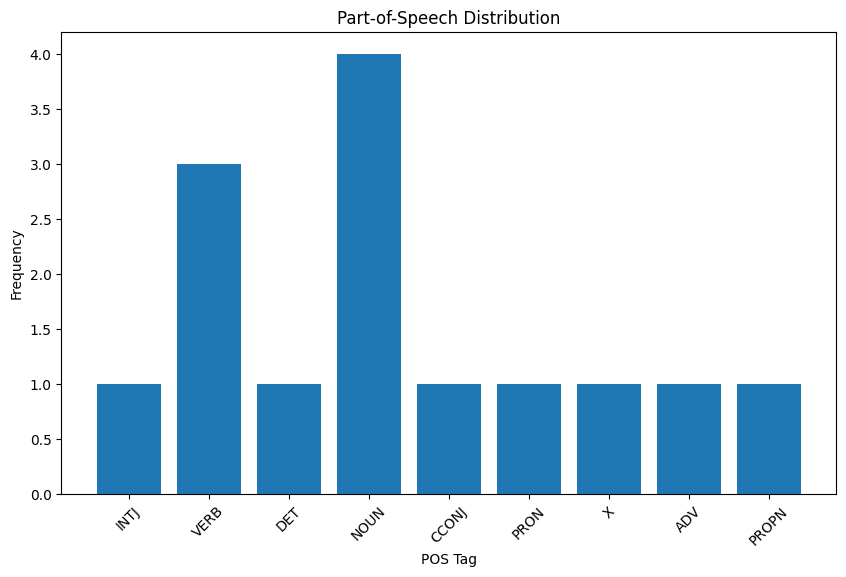

In [14]:
# Cell 5: Visualization of POS Distribution
# Count POS tags
pos_counts = {}
for token in doc:
    if not token.is_space and not token.is_punct:
        pos = token.pos_
        pos_counts[pos] = pos_counts.get(pos, 0) + 1

# Create visualization
plt.figure(figsize=(10, 6))
plt.bar(pos_counts.keys(), pos_counts.values())
plt.title('Part-of-Speech Distribution')
plt.xlabel('POS Tag')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()

In [15]:
# Cell 1: Setup
import spacy
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

# Load the appropriate model
use_gpu = torch.cuda.is_available()
nlp = spacy.load("en_core_web_trf") if use_gpu else spacy.load("en_core_web_sm")

In [16]:
# Cell 2: POS Tagging Analysis
def pos_tagging_analysis(doc):
    """Perform POS tagging analysis"""
    # Universal POS tags
    pos_counts = Counter([token.pos_ for token in doc if not token.is_space])
    
    # Detailed POS tags (English-specific)
    tag_counts = Counter([token.tag_ for token in doc if not token.is_space])
    
    # Create DataFrames for display
    pos_df = pd.DataFrame.from_dict(pos_counts, orient='index', columns=['Count']).reset_index()
    pos_df.columns = ['POS Tag', 'Count']
    pos_df = pos_df.sort_values('Count', ascending=False)
    
    tag_df = pd.DataFrame.from_dict(tag_counts, orient='index', columns=['Count']).reset_index()
    tag_df.columns = ['Detailed Tag', 'Count']
    tag_df = tag_df.sort_values('Count', ascending=False).head(10)
    
    return pos_df, tag_df

# Run analysis
pos_df, tag_df = pos_tagging_analysis(doc)

print("Universal POS Tags:")
display(pos_df)

print("\nTop 10 Detailed POS Tags:")
display(tag_df)

Universal POS Tags:


,POS Tag,Count
3,NOUN,4
1,VERB,3
4,PUNCT,3
0,INTJ,1
2,DET,1
5,CCONJ,1
6,PRON,1
7,X,1
8,ADV,1
9,PROPN,1



Top 10 Detailed POS Tags:


,Detailed Tag,Count
3,NN,4
1,VB,3
8,.,2
0,UH,1
2,DT,1
4,HYPH,1
5,CC,1
6,PRP$,1
7,ADD,1
9,RB,1
